In [20]:
# Library set up
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.preprocessing import StandardScaler

import sys
import os
import joblib

# Lấy đường dẫn thư mục gốc (customer-churn-predictor)
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
if root_path not in sys.path:
    sys.path.append(root_path)

from core.transformer import ChurnFeatureTransformer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


#### **1. Loading Raw Data**

In [2]:
df = pd.read_csv("../data/raw/train.csv")
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


#### **2. Dropping Unnecessary Features and Missing Values**

The Dropping features are the results of EDA part, ensuring model efficiency and simplicty

In [3]:
print('Data shape before Dropping', df.shape)
df = df.drop(
    ["CustomerID", "Tenure", "Usage Frequency", "Subscription Type", "Contract Length"], axis=1
)

df = df.dropna()
print('Data shape after Dropping', df.shape)
df.head()

Data shape before Dropping (440832, 12)
Data shape after Dropping (440832, 7)


,Age,Gender,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
0,30.0,Female,5.0,18.0,932.0,17.0,1.0
1,65.0,Female,10.0,8.0,557.0,6.0,1.0
2,55.0,Female,6.0,18.0,185.0,3.0,1.0
3,58.0,Male,7.0,7.0,396.0,29.0,1.0
4,23.0,Male,5.0,8.0,617.0,20.0,1.0


#### **3. Ensuring Data Type**

In [4]:
# int 
df['Churn'] = df['Churn'].astype(int)
df['Age'] = df['Age'].astype(int)
df['Support Calls'] = df['Support Calls'].astype(int) # Number of calls
df['Payment Delay'] = df['Payment Delay'].astype(int) # Days 
df['Last Interaction'] = df['Last Interaction'].astype(int) # Days ago

# float
df['Total Spend'] = df['Total Spend'].astype(float) # Currency Units

# Category
df['Gender'] = df['Gender'].astype('category')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440832 entries, 0 to 440831
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   Age               440832 non-null  int32   
 1   Gender            440832 non-null  category
 2   Support Calls     440832 non-null  int32   
 3   Payment Delay     440832 non-null  int32   
 4   Total Spend       440832 non-null  float64 
 5   Last Interaction  440832 non-null  int32   
 6   Churn             440832 non-null  int32   
dtypes: category(1), float64(1), int32(5)
memory usage: 12.2 MB


#### **4. OHE Gender**

Transform `Gender` into Binary feature `Male`, where `Male == 0` means customer is Female and `Male == 1` means otherwise


In [5]:
gender_ohe = pd.get_dummies(df["Gender"], dtype=np.int8)
df = df.drop(["Gender"], axis=1)
df = df.join(gender_ohe)
df = df.drop(columns= 'Female')
df.head()

,Age,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Male
0,30,5,18,932.0,17,1,0
1,65,10,8,557.0,6,1,0
2,55,6,18,185.0,3,1,0
3,58,7,7,396.0,29,1,1
4,23,5,8,617.0,20,1,1


#### **5. Binning Numerical Features**

#### **5.1. Age Groups**

As we discuss in EDA Part: 
- Group Aldult (25 - 39 years old) has the lowest churn rate, while Senior (> 60 years old) has 100% churn rate
- The two remaining group Young Aldult (18-24) and Mid-Career (40-59) has similar churn rate (~ 55%)

Thus we will binning Age into groups as follows:

In [6]:
def classify_age_group(age):
    if 18 <= age <= 24:
        return "Young Adult"
    elif 24 < age <= 39:
        return "Adult"
    elif 39 < age <= 59:
        return "Mid-Career"
    elif age >= 60:
        return "Senior"


df["Age Group"] = df["Age"].apply(classify_age_group)
df.head()

,Age,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Male,Age Group
0,30,5,18,932.0,17,1,0,Adult
1,65,10,8,557.0,6,1,0,Senior
2,55,6,18,185.0,3,1,0,Mid-Career
3,58,7,7,396.0,29,1,1,Mid-Career
4,23,5,8,617.0,20,1,1,Young Adult


In [7]:
df["Age Group"].value_counts()

Age Group
Mid-Career     186203
Adult          157952
Young Adult     64036
Senior          32641
Name: count, dtype: int64

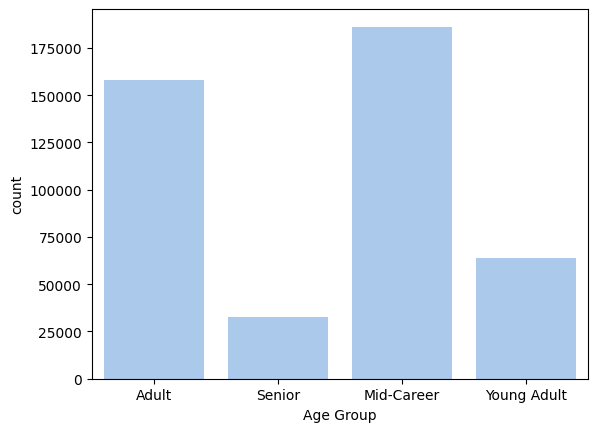

In [33]:
sns.set_palette("pastel")

sns.countplot(data=df, x="Age Group")
plt.show()

#### **5.2. Last Interaction**

To better capture customer behavior, we transformed the continuous variable Last Interaction into a categorical feature using a Binning technique. This helps the model identify non-linear patterns and risk thresholds more effectively.

Logic Breakdown:
- Highly Active (0 - 7 days): Customers who interacted within the last week. This group represents the most engaged users with the lowest churn risk.

- Active (8 - 15 days): Customers who haven't interacted in over a week but stayed within a 15-day window. They are stable but may require re-engagement.

- Dormant (> 15 days): Customers with no activity for more than two weeks. This is the high-risk zone where users are most likely to churn.

In [8]:
def classify_interaction_frequency(last_interaction):
    if 0 < last_interaction <= 7:
        return "Highly Active"
    elif 7 < last_interaction <= 15:
        return "Active"
    elif last_interaction > 15:
        return "Dormant"


df["Interaction Frequency"] = df["Last Interaction"].apply(
    classify_interaction_frequency
)
df.head()

,Age,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Male,Age Group,Interaction Frequency
0,30,5,18,932.0,17,1,0,Adult,Dormant
1,65,10,8,557.0,6,1,0,Senior,Highly Active
2,55,6,18,185.0,3,1,0,Mid-Career,Highly Active
3,58,7,7,396.0,29,1,1,Mid-Career,Dormant
4,23,5,8,617.0,20,1,1,Young Adult,Dormant


In [9]:
df['Interaction Frequency'].value_counts(dropna=False)

Interaction Frequency
Dormant          190437
Active           133354
Highly Active    117041
Name: count, dtype: int64

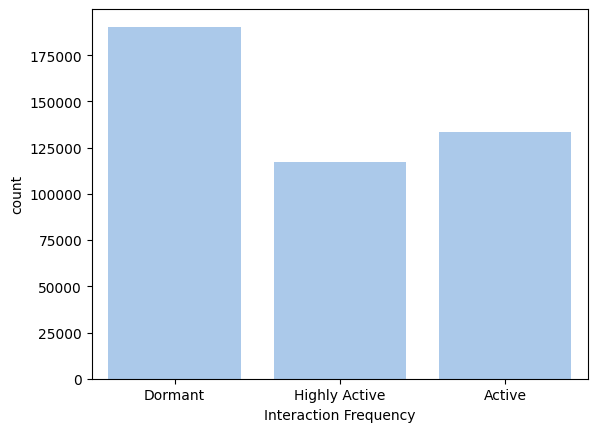

In [24]:
sns.countplot(data=df, x="Interaction Frequency")
plt.show()

#### **5.3. Mapping Age Groups and Interaction Frequency**

This step ensuring the datatype of new binning features are suitable for model input 

In [10]:
age_mapping = {"Young Adult": 0, "Adult": 1, "Mid-Career": 2, "Senior": 3}

interaction_mapping = {"Highly Active": 0, "Active": 1, "Dormant": 2}

df["Age Group"] = df["Age Group"].apply(lambda age: age_mapping[age])
df["Interaction Frequency"] = df["Interaction Frequency"].apply(
    lambda age: interaction_mapping[age]
)
df.head()

,Age,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Male,Age Group,Interaction Frequency
0,30,5,18,932.0,17,1,0,1,2
1,65,10,8,557.0,6,1,0,3,0
2,55,6,18,185.0,3,1,0,2,0
3,58,7,7,396.0,29,1,1,2,2
4,23,5,8,617.0,20,1,1,0,2


#### **6. Scaler (fit for Train dataset only)**

In [11]:
scaler = StandardScaler()
df_no_label = df.drop(["Churn"], axis=1)
df_no_label = pd.DataFrame(
    scaler.fit_transform(df_no_label), columns=df_no_label.columns
)
df_no_label.head()

,Age,Support Calls,Payment Delay,Total Spend,Last Interaction,Male,Age Group,Interaction Frequency
0,-0.753326,0.454549,0.609620,1.247427,0.293052,-1.145909,-0.514510,1.018461
1,2.059646,2.083100,-0.601319,-0.309865,-0.986584,-1.145909,1.905480,-1.425340
2,1.255940,0.780259,0.609620,-1.854698,-1.335575,-1.145909,0.695485,-1.425340
3,1.497051,1.105969,-0.722413,-0.978462,1.689018,0.872670,0.695485,1.018461
4,-1.315921,0.454549,-0.601319,-0.060698,0.642043,0.872670,-1.724505,1.018461


In [12]:
df = df_no_label.join(df["Churn"])
df.head()

,Age,Support Calls,Payment Delay,Total Spend,Last Interaction,Male,Age Group,Interaction Frequency,Churn
0,-0.753326,0.454549,0.609620,1.247427,0.293052,-1.145909,-0.514510,1.018461,1
1,2.059646,2.083100,-0.601319,-0.309865,-0.986584,-1.145909,1.905480,-1.425340,1
2,1.255940,0.780259,0.609620,-1.854698,-1.335575,-1.145909,0.695485,-1.425340,1
3,1.497051,1.105969,-0.722413,-0.978462,1.689018,0.872670,0.695485,1.018461,1
4,-1.315921,0.454549,-0.601319,-0.060698,0.642043,0.872670,-1.724505,1.018461,1


#### **7. Rerunning with Pipeline**

In [32]:
# 0. raw data
df_raw = pd.read_csv("../data/raw/train.csv").drop(columns = 'CustomerID')

Churn = df['Churn']
df_raw = df_raw.drop(columns = 'Churn')

# 1. Khởi tạo Pipeline
preprocesing_pipeline = Pipeline([
    ('stateless_transform', ChurnFeatureTransformer()),
    ('scaler', StandardScaler())
])

# 2. Cấu hình output (chỉ cho scaler để tránh lỗi ValueError trước đó)
preprocesing_pipeline.named_steps['scaler'].set_output(transform="pandas")

df_processed = preprocesing_pipeline.fit_transform(
    df_raw, 
    stateless_transform__train=True
)

# Dùng pd.concat với axis=1 để nối theo cột, Pandas sẽ tự động khớp theo Index
df_final = pd.concat([df_processed, Churn], axis=1)
df_final.head()

,Age,Support Calls,Payment Delay,Total Spend,Last Interaction,Male,Age_Group,Interaction_Frequency,Churn
0,-0.753326,0.454549,0.609620,1.247427,0.293052,-1.145909,-0.514510,1.018461,1
1,2.059646,2.083100,-0.601319,-0.309865,-0.986584,-1.145909,1.905480,-1.425340,1
2,1.255940,0.780259,0.609620,-1.854698,-1.335575,-1.145909,0.695485,-1.425340,1
3,1.497051,1.105969,-0.722413,-0.978462,1.689018,0.872670,0.695485,1.018461,1
4,-1.315921,0.454549,-0.601319,-0.060698,0.642043,0.872670,-1.724505,1.018461,1


#### **8. Saving**

In [34]:
os.makedirs("../data/preprocessed", exist_ok=True)
df_final.to_parquet("../data/preprocessed/train.parquet", index=False)

# LƯU PIPELINE
# Tạo thư mục models nếu chưa có
os.makedirs("../models", exist_ok=True)

model_path = "../models/preprocessing_pipeline.joblib"
joblib.dump(preprocesing_pipeline, model_path)

print(f"\n✅ Đã lưu pipeline tại: {model_path}")


✅ Đã lưu pipeline tại: ../models/preprocessing_pipeline.joblib
